# Machine Learning 1 - Ingeniería Electrónica
## Práctica de Preprocesamiento de Datos: Limpieza, Imputación, Normalización, Detección de Outliers y PCA

---

El preprocesamiento riguroso de datos es el pilar fundamental para construir modelos de Machine Learning robustos y generalizables. Esta práctica aborda de manera metódica y pedagógica las etapas esenciales del flujo de trabajo de datos (*Data Preparation Pipeline*)

In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, precision_recall_fscore_support
from scipy import stats

# Configuración global de visualización
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)


## 1. Fuentes de Datos, Documentación de Datasets y Adquisición Automatizada desde Internet

### Documentación Detallada de los Datasets Utilizados:

#### A. Titanic Open Dataset (Tabular CSV)
- **Origen**: Registro histórico del hundimiento del RMS Titanic (1912).
- **Dimensiones**: $891$ filas $\times 12$ columnas.
- **Variable Objetivo (*Target*)**: `Survived` ($0$: No sobrevivió, $1$: Sobrevivió).
- **Diccionario de Atributos**:
  - `PassengerId` (*int64*): Identificador único correlativo del pasajero.
  - `Survived` (*int64*): Estado de supervivencia ($0$ o $1$).
  - `Pclass` (*int64*): Clase del boleto ($1$: Primera, $2$: Segunda, $3$: Tercera clase).
  - `Name` (*str*): Nombre completo del pasajero con título de cortesía.
  - `Sex` (*str*): Género (`male`, `female`).
  - `Age` (*float64*): Edad en años ($177$ nulos / $19.87\%$ de ausencia, patrón MAR).
  - `SibSp` (*int64*): Número de hermanos/cónyuges a bordo.
  - `Parch` (*int64*): Número de padres/hijos a bordo.
  - `Ticket` (*str*): Número/código del billete de abordaje.
  - `Fare` (*float64*): Tarifa pagada por el billete (contiene outliers severos por tarifas ejecutivas de primera clase).
  - `Cabin` (*str*): Número de camarote ($687$ nulos / $77.10\%$ de ausencia, patrón MCAR/MAR).
  - `Embarked` (*str*): Puerto de embarque (`C`: Cherbourg, `Q`: Queenstown, `S`: Southampton; $2$ nulos / $0.22\%$).

#### B. Dataset Personas (CSV Masivo en ZIP - `personas_202607262153.zip`)
- **Origen**: Registro civil institucional de identificación ciudadana (~1 GB comprimido).
- **Dimensiones**: Muestra activa de $100,000$ filas $\times 14$ columnas.
- **Atributos Clave**:
  - `cedula` (*int64/str*): Número de Cédula de Identidad (CI), emitido secuencialmente en el tiempo.
  - `fechNacim` (*str*): Fecha y hora de nacimiento con formato ISO 8601 y zonas horarias mixtas.
  - `sexo` (*str*): Género registrado (`F`, `M`).
  - `estadoCivil` (*str*): Estado civil codificado.
  - `profesionBean`, `icActa`, `icTomo`, `icFolio`: Metadatos de acta de nacimiento (presentan hasta $>85\%$ nulos).
- **Objetivo de ML**: Entrenar un algoritmo de regresión/estimación que infiera la edad a partir del número de Cédula de Identidad (`cedula`), requiriendo la detección y eliminación de inconsistencias (outliers por tipeo manual o fechas corruptas).

#### C. Dataset Olivetti Real Faces (Imágenes Reales)
- **Origen**: Laboratorio de Investigación de AT&T / Cambridge University.
- **Dimensiones**: $400$ imágenes en escala de grises de $64 \times 64$ píxeles ($D = 4096$ dimensiones por imagen).
- **Rango de Intensidad**: $[0, 255]$ ($uint8$).
- **Objetivo de ML**: Visión por Computadora y Detección de Anomalías (*Anomaly Detection*) mediante error de reconstrucción en PCA tras la inyección controlada de $5$ anomalías ópticas etiquetadas (*Ground Truth*):
  1. `Subexpuesta / Pitch Black` (píxeles $\approx 0$).
  2. `Sobreexpuesta / Saturada` (píxeles $\approx 255$).
  3. `Ruido Masivo Estática` (máscara de ruido Sal y Pimienta).
  4. `Inversión Anómala` (inversión de intensidad $255 - I$).

---

### Fundamentación Matemática de Ausencia de Datos:
Sea $M \in \{0, 1\}$ la variable indicadora de ausencia ($M=1$ si el dato falta, $M=0$ si está observado), $Y_{obs}$ el conjunto de datos observados y $Y_{mis}$ los datos faltantes:

1. **MCAR** (*Missing Completely at Random*):
   La probabilidad de que un dato sea nulo es totalmente independiente tanto de las variables observadas como de las no observadas:
   $$P(M | Y_{obs}, Y_{mis}) = P(M)$$
   - *Donde*:
     - $M$: Indicador de estado nulo/observado.
     - $Y_{obs}$: Matriz de datos observados.
     - $Y_{mis}$: Matriz de datos faltantes/omitidos.
     - $P(M)$: Probabilidad marginal constante de ausencia.

2. **MAR** (*Missing at Random*):
   La probabilidad de ausencia depende de variables observadas ($Y_{obs}$), pero no del propio valor faltante ($Y_{mis}$):
   $$P(M | Y_{obs}, Y_{mis}) = P(M | Y_{obs})$$
   - *Donde*:
     - $P(M | Y_{obs})$: Probabilidad condicional basada exclusivamente en los atributos registrados (ej. la edad falta más frecuentemente en pasajeros de tercera clase).

3. **MNAR** (*Missing Not at Random*):
   La probabilidad de ausencia depende directamente del propio valor no observado ($Y_{mis}$):
   $$P(M | Y_{obs}, Y_{mis}) = P(M | Y_{obs}, Y_{mis})$$
   - *Donde*:
     - La omisión está sesgada por el valor real no registrado (ej. personas con ingresos muy altos que evitan declarar su salario).

In [71]:
def download_csv_dataset(url: str) -> pd.DataFrame:
    """Descarga un dataset CSV desde una URL pública."""
    print(f"Descargando datos desde: {url} ...")
    df = pd.read_csv(url)
    print(f"Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
    return df

url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = download_csv_dataset(url_titanic)

Descargando datos desde: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv ...
Dataset cargado con éxito. Dimensiones: 891 filas x 12 columnas.


In [72]:
def inspect_data_quality(df: pd.DataFrame):
    """Muestra métricas completas de nulos, porcentajes y tipos de datos."""
    summary_df = pd.DataFrame({
        'Tipo_Dato': df.dtypes.astype(str),
        'Valores_Nulos': df.isnull().sum(),
        'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Valores_Unicos': df.nunique()
    })
    print("\n--- RESUMEN DE ESTRUCTURA Y CALIDAD DE DATOS ---")
    display(summary_df)

inspect_data_quality(df_raw)


--- RESUMEN DE ESTRUCTURA Y CALIDAD DE DATOS ---


,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos (%),Valores_Unicos
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


## 2. Limpieza de Datos Tabulares: Eliminación Directa (`dropna`) e Imputación

### Formulaciones Matemáticas Desglosadas de Imputación:

1. **Media Univariada**:
   $$\bar{x} = \frac{1}{N_{obs}} \sum_{i \in Obs} x_i$$
   - *Donde*:
     - $\bar{x}$: Valor medio estimado que sustituirá a los nulos de la variable $X$.
     - $N_{obs}$: Número total de observaciones válidas (no nulas) en la columna.
     - $x_i$: Valor de la variable en la fila $i$.
     - $Obs$: Conjunto de índices donde la variable $X$ está observada.

2. **Mediana Univariada**:
   $$Med(X) = P_{50}(X)$$
   - *Donde*:
     - $Med(X)$: Percentil 50 de la variable $X$, inmune a la presencia de outliers extremas.

3. **Distancia Euclídea Ponderada en `KNNImputer`**:
   Para imputar el valor de una muestra $x$ que contiene atributos faltantes utilizando una muestra vecina $p$:
   $$d(x, p) = \sqrt{\frac{m}{m_{obs}} \sum_{k \in Obs} w_k (x_k - p_k)^2}$$
   - *Donde*:
     - $d(x, p)$: Distancia Euclídea ajustada entre la instancia incompleta $x$ y la muestra candidata $p$.
     - $m$: Número total de características/columnas numéricas en el dataset.
     - $m_{obs}$: Número de atributos simultáneamente presentes (no nulos) en ambas muestras $x$ y $p$.
     - $\frac{m}{m_{obs}}$: Factor de escala compensatorio para escalar la distancia si faltan atributos.
     - $w_k$: Peso asignado a la característica $k$ (por defecto $w_k = 1$).
     - $x_k, p_k$: Valores del atributo $k$ en los puntos $x$ y $p$ respectivamente.

Para evitar la **fuga de información (*Data Leakage*)**, la partición en conjuntos de **Train** (80%) y **Validation/Test** (20%) se realiza **antes** de ajustar cualquier transformador.

In [73]:
# Partición estricta de datos en Train (80%) y Validation/Test (20%)
df_train, df_test = train_test_split(df_raw, test_size=0.20, random_state=42)
print(f"Tamaño Conjunto de Entrenamiento (Train): {df_train.shape[0]} filas")
print(f"Tamaño Conjunto de Validación/Test (Test):   {df_test.shape[0]} filas")

Tamaño Conjunto de Entrenamiento (Train): 712 filas
Tamaño Conjunto de Validación/Test (Test):   179 filas


In [74]:
def preprocess_tabular_features(df_tr: pd.DataFrame, df_te: pd.DataFrame) -> tuple:
    """Aplica eliminación directa (dropna) e imputación calculada SOLO en Train."""
    tr = df_tr.copy()
    te = df_te.copy()
    
    # 1. Remoción de duplicados en Train
    tr = tr.drop_duplicates()
    
    # 2. Demostración de Eliminación Directa (dropna) en filas con nulos en 'Embarked'
    print(f"Filas en Train antes de dropna('Embarked'): {len(tr)}")
    tr = tr.dropna(subset=['Embarked']).copy()
    te = te.dropna(subset=['Embarked']).copy()
    print(f"Filas en Train después de dropna('Embarked'): {len(tr)}")
    
    # 3. Variable indicadora Has_Cabin y descarte de columna Cabin (>77% nulos)
    for d in [tr, te]:
        d['Has_Cabin'] = d['Cabin'].notnull().astype(int)
        d.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True, errors='ignore')
        
    # 4. Imputación Categórica por Moda
    imp_cat = SimpleImputer(strategy='most_frequent')
    tr['Embarked'] = imp_cat.fit_transform(tr[['Embarked']]).ravel()
    te['Embarked'] = imp_cat.transform(te[['Embarked']]).ravel()
    
    # 5. Imputación Numérica KNN (k=5 vecinos)
    num_cols = ['Pclass', 'SibSp', 'Parch', 'Fare', 'Age']
    knn_imp = KNNImputer(n_neighbors=5)
    
    tr[num_cols] = knn_imp.fit_transform(tr[num_cols])
    te[num_cols] = knn_imp.transform(te[num_cols])
    
    return tr, te

df_train_clean, df_test_clean = preprocess_tabular_features(df_train, df_test)
print("Preprocesamiento tabulares e imputación completada sin Data Leakage.")

Filas en Train antes de dropna('Embarked'): 712
Filas en Train después de dropna('Embarked'): 710
Preprocesamiento tabulares e imputación completada sin Data Leakage.


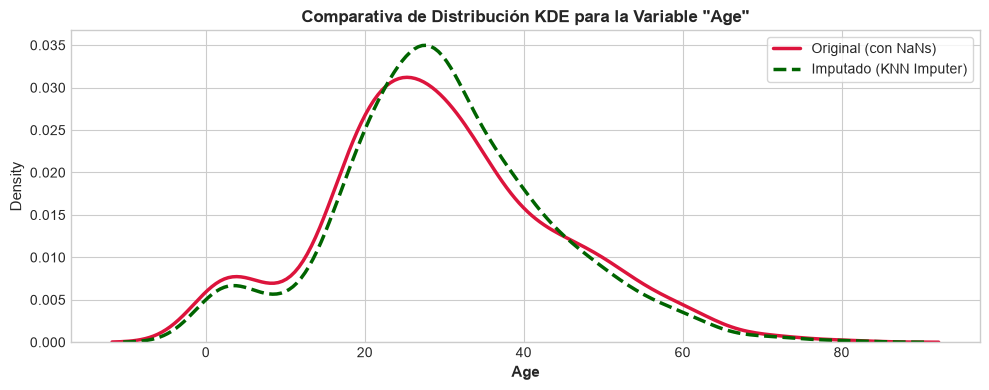

In [75]:
def plot_imputation_results(df_orig: pd.DataFrame, df_clean: pd.DataFrame, feature: str = 'Age'):
    """Compara visualmente la distribución antes y después de imputar."""
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.kdeplot(df_orig[feature].dropna(), ax=ax, color='crimson', label='Original (con NaNs)', linewidth=2.5)
    sns.kdeplot(df_clean[feature], ax=ax, color='darkgreen', label='Imputado (KNN Imputer)', linestyle='--', linewidth=2.5)
    ax.set_title(f'Comparativa de Distribución KDE para la Variable "{feature}"', fontweight='bold')
    ax.set_xlabel(feature, fontweight='bold')
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

plot_imputation_results(df_train, df_train_clean, 'Age')

## 3. Normalización y Escalado de Características: Protocolo de Normalización Independiente (Train vs. Test)

### Regla Fundamental contra la Fuga de Información (*Data Leakage*):
En Machine Learning, el ajuste de escaladores (`fit` o `fit_transform`) se realiza **EXCLUSIVAMENTE en el conjunto de Entrenamiento ($X_{train}$)**. El conjunto de Validación/Prueba ($X_{test}$) debe ser transformado únicamente (`transform`) utilizando los parámetros ($\mu_{train}, \sigma_{train}, x_{min, train}, x_{max, train}$) calculados en *Train*.

#### Formulaciones Matemáticas de Normalización Independiente:

1. **Estandarización Z-Score (`StandardScaler`)**:
   $$z_{train} = \frac{x_{train} - \mu_{train}}{\sigma_{train}}, \quad z_{test} = \frac{x_{test} - \mu_{train}}{\sigma_{train}}$$
   - *Donde*:
     - $z_{train}, z_{test}$: Valores estandarizados en entrenamiento y validación respectivamente.
     - $x_{train}, x_{test}$: Observaciones originales no escaladas.
     - $\mu_{train}$: Media aritmética estimada **únicamente** en $X_{train}$ ($\mu_{train} = \frac{1}{N_{train}} \sum x_{train, i}$).
     - $\sigma_{train}$: Desviación estándar estimada **únicamente** en $X_{train}$ ($\sigma_{train} = \sqrt{\frac{1}{N_{train}} \sum (x_{train, i} - \mu_{train})^2}$).

2. **Escalado Min-Max (`MinMaxScaler`)**:
   $$x_{norm, train} = \frac{x_{train} - x_{min, train}}{x_{max, train} - x_{min, train}}, \quad x_{norm, test} = \frac{x_{test} - x_{min, train}}{x_{max, train} - x_{min, train}}$$
   - *Donde*:
     - $x_{min, train}, x_{max, train}$: Mínimo y máximo absolutos observados exclusivamente en $X_{train}$.

3. **Escalado Robusto (`RobustScaler`)**:
   $$x_{rob, train} = \frac{x_{train} - Med(X_{train})}{IQR(X_{train})}, \quad x_{rob, test} = \frac{x_{test} - Med(X_{train})}{IQR(X_{train})}$$
   - *Donde*:
     - $Med(X_{train}) = P_{50, train}$: Mediana muestral en $X_{train}$.
     - $IQR(X_{train}) = P_{75, train} - P_{25, train}$: Rango intercuartílico estimado en $X_{train}$.

In [76]:
def compare_normalization_methods_summary(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """Genera una tabla comparativa de métricas estadísticas antes y después de escalar."""
    data = df[features].copy()
    
    scalers = {
        'Original (No Normalizado)': None,
        'StandardScaler (Z-Score)': StandardScaler(),
        'MinMaxScaler ([0, 1])': MinMaxScaler(),
        'RobustScaler (Median/IQR)': RobustScaler()
    }
    
    summary_rows = []
    for name, scaler in scalers.items():
        if scaler is None:
            scaled_df = data.copy()
        else:
            scaled_array = scaler.fit_transform(data)
            scaled_df = pd.DataFrame(scaled_array, columns=features)
            
        for col in features:
            summary_rows.append({
                'Método de Escalado': name,
                'Variable': col,
                'Media': round(scaled_df[col].mean(), 4),
                'Desv_Std': round(scaled_df[col].std(), 4),
                'Mínimo': round(scaled_df[col].min(), 4),
                'Mediana (P50)': round(scaled_df[col].median(), 4),
                'Máximo': round(scaled_df[col].max(), 4),
                'IQR': round(scaled_df[col].quantile(0.75) - scaled_df[col].quantile(0.25), 4)
            })
            
    summary_table = pd.DataFrame(summary_rows)
    print("\n================ TABLA COMPARATIVA DE MÉTRICAS ESTADÍSTICAS POR ESCALADOR ================")
    display(summary_table)
    return summary_table

df_scaling_comparison = compare_normalization_methods_summary(df_train_clean, ['Age', 'Fare'])


================ TABLA COMPARATIVA DE MÉTRICAS ESTADÍSTICAS POR ESCALADOR ================


,Método de Escalado,Variable,Media,Desv_Std,Mínimo,Mediana (P50),Máximo,IQR
0,Original (No Normalizado),Age,29.8059,13.4141,0.4200,29.0000,80.0000,15.2000
1,Original (No Normalizado),Fare,32.4527,51.9816,0.0000,14.4271,512.3292,22.4677
2,StandardScaler (Z-Score),Age,-0.0000,1.0007,-2.1922,-0.0601,3.7445,1.1339
3,StandardScaler (Z-Score),Fare,0.0000,1.0007,-0.6248,-0.3470,9.2382,0.4325
4,"MinMaxScaler ([0, 1])",Age,0.3693,0.1686,0.0000,0.3591,1.0000,0.1910
5,"MinMaxScaler ([0, 1])",Fare,0.0633,0.1015,0.0000,0.0282,1.0000,0.0439
6,RobustScaler (Median/IQR),Age,0.0530,0.8825,-1.8803,0.0000,3.3553,1.0000
7,RobustScaler (Median/IQR),Fare,0.8023,2.3136,-0.6421,0.0000,22.1608,1.0000


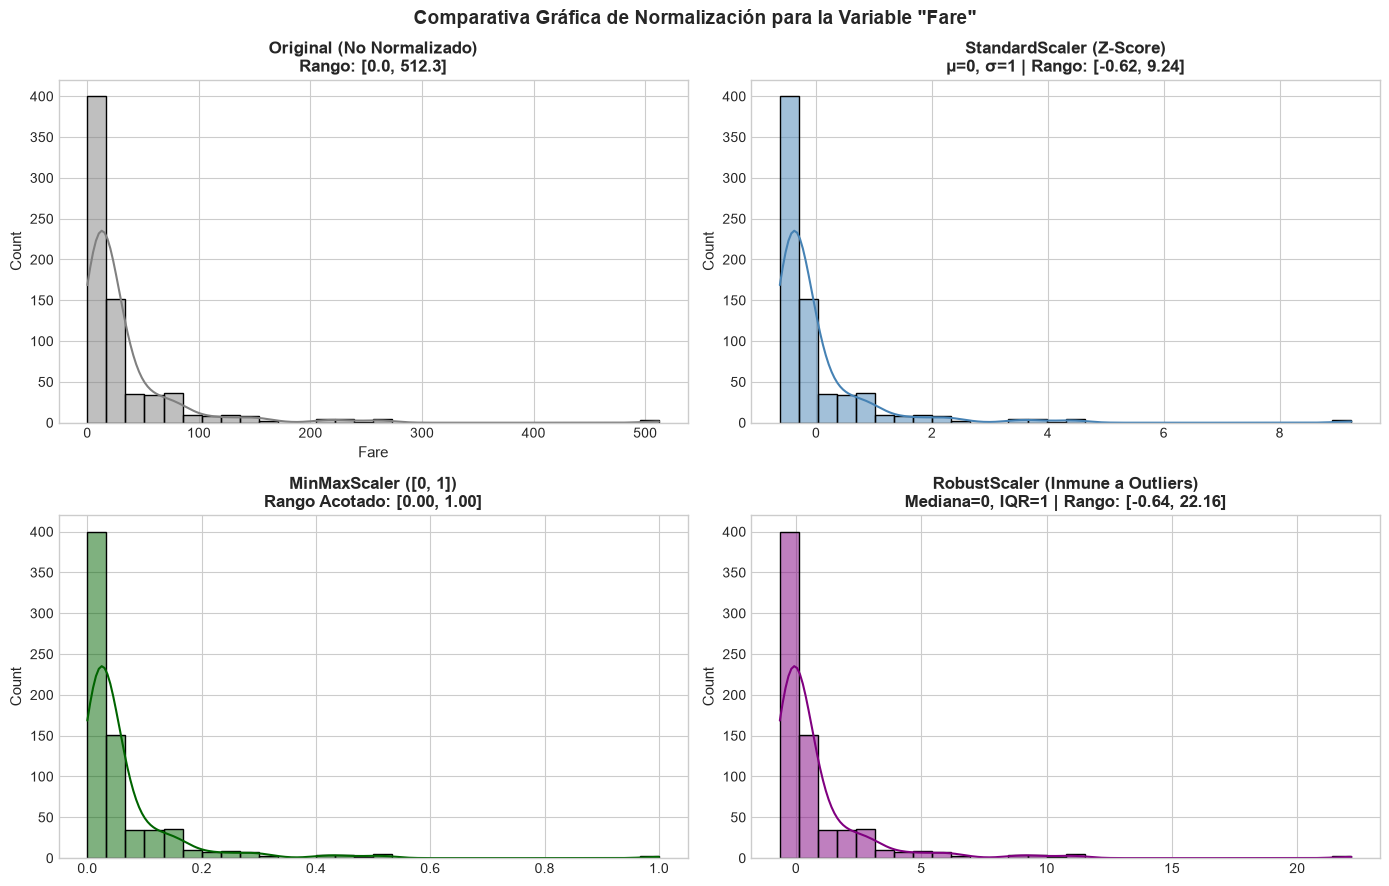

In [77]:
def plot_normalization_comparison_dashboard(df: pd.DataFrame, feature: str = 'Fare'):
    """Grafica visualmente el impacto de los métodos de normalización en la distribución."""
    data = df[[feature]].copy()
    
    std_data = StandardScaler().fit_transform(data).ravel()
    minmax_data = MinMaxScaler().fit_transform(data).ravel()
    robust_data = RobustScaler().fit_transform(data).ravel()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'Comparativa Gráfica de Normalización para la Variable "{feature}"', fontsize=14, fontweight='bold')
    
    # 1. Original (No Normalizado)
    sns.histplot(data[feature], kde=True, ax=axes[0, 0], color='gray', bins=30)
    axes[0, 0].set_title(f'Original (No Normalizado)\nRango: [{data[feature].min():.1f}, {data[feature].max():.1f}]', fontweight='bold')
    
    # 2. StandardScaler (Z-Score)
    sns.histplot(std_data, kde=True, ax=axes[0, 1], color='steelblue', bins=30)
    axes[0, 1].set_title(f'StandardScaler (Z-Score)\nμ=0, σ=1 | Rango: [{std_data.min():.2f}, {std_data.max():.2f}]', fontweight='bold')
    
    # 3. MinMaxScaler ([0, 1])
    sns.histplot(minmax_data, kde=True, ax=axes[1, 0], color='darkgreen', bins=30)
    axes[1, 0].set_title(f'MinMaxScaler ([0, 1])\nRango Acotado: [{minmax_data.min():.2f}, {minmax_data.max():.2f}]', fontweight='bold')
    
    # 4. RobustScaler (Median / IQR)
    sns.histplot(robust_data, kde=True, ax=axes[1, 1], color='purple', bins=30)
    axes[1, 1].set_title(f'RobustScaler (Inmune a Outliers)\nMediana=0, IQR=1 | Rango: [{robust_data.min():.2f}, {robust_data.max():.2f}]', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_normalization_comparison_dashboard(df_train_clean, 'Fare')

## 4. Detección y Verificación de Outliers en Datos Tabulares

### Formulaciones Matemáticas Desglosadas de Detectores de Outliers:

1. **Criterio de Rango Intercuartílico (IQR)**:
   $$IQR = Q_3 - Q_1$$
   $$\text{Límite Inferior} = Q_1 - 1.5 \times IQR, \quad \text{Límite Superior} = Q_3 + 1.5 \times IQR$$
   - *Donde*:
     - $Q_1 = P_{25}$: Primer cuartil (25% de los datos por debajo).
     - $Q_3 = P_{75}$: Tercer cuartil (75% de los datos por debajo).
     - $IQR$: Rango intercuartílico que mide la dispersión del 50% central de los datos.
     - $1.5$: Factor de escala estándar definido por John Tukey para identificar anomalías moderadas.

2. **Puntaje de Anomalía en Isolation Forest**:
   $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
   - *Donde*:
     - $s(x, n)$: Puntaje de anomalía para la muestra $x$ ($s \to 1$ indica anomalía clara, $s < 0.5$ indica observación normal).
     - $h(x)$: Longitud del camino de aislamiento (número de divisiones de bordes para aislar la muestra $x$).
     - $E(h(x))$: Valor esperado / promedio de la profundidad $h(x)$ en todos los árboles de decisión del bosque.
     - $c(n)$: Longitud promedio del camino no exitoso en un árbol binario de búsqueda ajustado a $n$ muestras:
       $$c(n) = 2 (\ln(n - 1) + 0.5772156649) - \frac{2(n - 1)}{n}$$
     - $n$: Número total de muestras utilizadas para construir cada árbol.

In [78]:
def fit_outlier_detectors(df_tr: pd.DataFrame, target_col: str = 'Fare') -> dict:
    """Ajusta detectores de outliers calculando parámetros ÚNICAMENTE en Train."""
    q1 = df_tr[target_col].quantile(0.25)
    q3 = df_tr[target_col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_forest.fit(df_tr[[target_col]])
    
    params = {
        'iqr_lower': lower_bound,
        'iqr_upper': upper_bound,
        'iso_model': iso_forest
    }
    print(f"Límite Superior IQR (calculado en Train): ${upper_bound:.2f}")
    return params

outlier_params = fit_outlier_detectors(df_train_clean, 'Fare')

Límite Superior IQR (calculado en Train): $64.09


In [79]:
def predict_and_verify_outliers(df: pd.DataFrame, params: dict, target_col: str = 'Fare') -> pd.DataFrame:
    """Aplica los detectores entrenados en Train sobre un conjunto de datos (Train o Test)."""
    d = df.copy()
    d['outlier_iqr'] = ((d[target_col] > params['iqr_upper']) | (d[target_col] < params['iqr_lower'])).astype(int)
    d['outlier_iso'] = (params['iso_model'].predict(d[[target_col]]) == -1).astype(int)
    return d

df_train_out = predict_and_verify_outliers(df_train_clean, outlier_params, 'Fare')
df_test_out = predict_and_verify_outliers(df_test_clean, outlier_params, 'Fare')

print("\n--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO TRAIN ---")
print(f"Total Registros: {len(df_train_out)}")
print(f"Outliers detectados por IQR en 'Fare': {df_train_out['outlier_iqr'].sum()} ({df_train_out['outlier_iqr'].mean()*100:.2f}%)")
print(f"Outliers detectados por Isolation Forest:     {df_train_out['outlier_iso'].sum()} ({df_train_out['outlier_iso'].mean()*100:.2f}%)")

print("\n--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO VALIDATION/TEST ---")
print(f"Total Registros: {len(df_test_out)}")
print(f"Outliers detectados por IQR en 'Fare': {df_test_out['outlier_iqr'].sum()} ({df_test_out['outlier_iqr'].mean()*100:.2f}%)")
print(f"Outliers detectados por Isolation Forest:     {df_test_out['outlier_iso'].sum()} ({df_test_out['outlier_iso'].mean()*100:.2f}%)")


--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO TRAIN ---
Total Registros: 710
Outliers detectados por IQR en 'Fare': 94 (13.24%)
Outliers detectados por Isolation Forest:     36 (5.07%)

--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO VALIDATION/TEST ---
Total Registros: 179
Outliers detectados por IQR en 'Fare': 22 (12.29%)
Outliers detectados por Isolation Forest:     6 (3.35%)


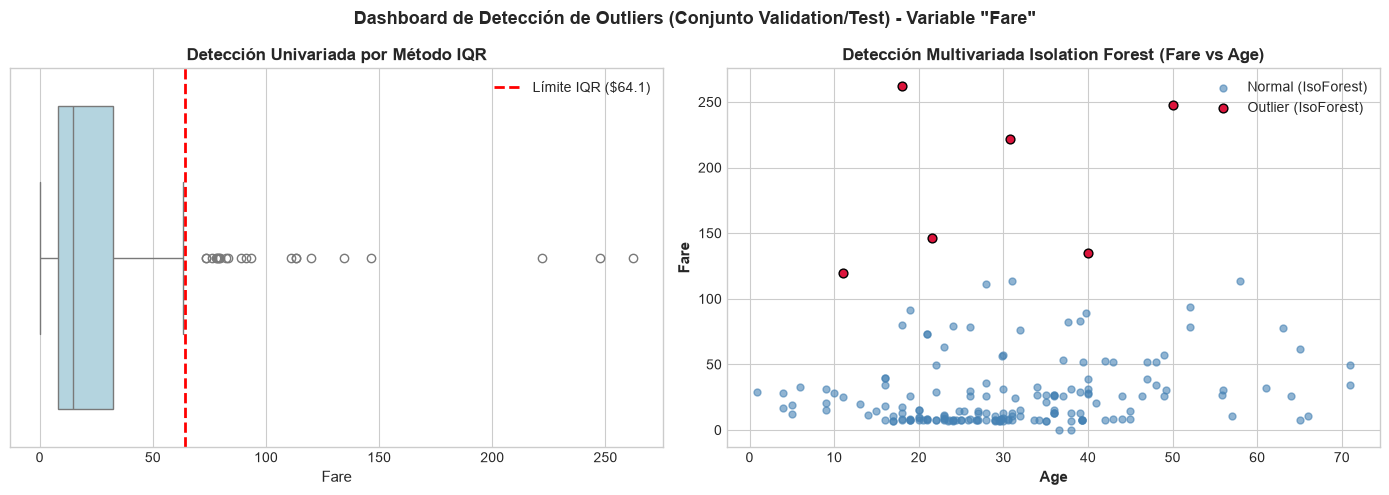

In [80]:
def plot_outliers_dashboard(df: pd.DataFrame, params: dict, set_name: str = 'Train'):
    """Genera dashboard gráfico de detección de outliers."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Dashboard de Detección de Outliers (Conjunto {set_name}) - Variable "Fare"', fontsize=13, fontweight='bold')
    
    sns.boxplot(x=df['Fare'], ax=ax1, color='lightblue')
    ax1.axvline(x=params['iqr_upper'], color='red', linestyle='--', linewidth=2, label=f'Límite IQR (${params["iqr_upper"]:.1f})')
    ax1.set_title('Detección Univariada por Método IQR', fontweight='bold')
    ax1.legend()
    
    normals = df[df['outlier_iso'] == 0]
    anomalies = df[df['outlier_iso'] == 1]
    ax2.scatter(normals['Age'], normals['Fare'], c='steelblue', label='Normal (IsoForest)', alpha=0.6, s=25)
    ax2.scatter(anomalies['Age'], anomalies['Fare'], c='crimson', label='Outlier (IsoForest)', s=40, edgecolors='black')
    ax2.set_title('Detección Multivariada Isolation Forest (Fare vs Age)', fontweight='bold')
    ax2.set_xlabel('Age', fontweight='bold')
    ax2.set_ylabel('Fare', fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_outliers_dashboard(df_test_out, outlier_params, 'Validation/Test')

### 4.B. Ejemplo Práctico de Dominio Real: Procesamiento de `personas_202607262153.zip` y Correlación Cédula vs. Año de Nacimiento

#### Caso de Uso de Inferencia de Edad
En bases de datos de registros ciudadanos, las Cédulas de Identidad (CI) son asignadas secuencialmente en el tiempo, existiendo una **fuerte correlación monótona** entre el número de Cédula y el **Año de Nacimiento** (o Edad).

Un algoritmo de Machine Learning que estime la edad a partir de la cédula requiere una fase previa de preprocesamiento:
1. **Eliminación de Nulos (`dropna`)** y corrección de zonas horarias mixtas (`utc=True`).
2. **Análisis de Correlación ($r$ de Pearson y $\rho$ de Spearman)**.
3. **Detección de Outliers por Regresión Lineal y residuales $Z > 3\sigma$**: Filtrar registros corruptos (ej. personas nacidas en 1904 asociadas a cédulas recientes) que distorsionarían el entrenamiento.

In [81]:
def load_personas_dataset_from_zip(zip_path: str, nrows: int = 100000) -> pd.DataFrame:
    """Lee el dataset masivo personas_202607262153.csv directamente desde el archivo ZIP."""
    print(f"Abriendo archivo ZIP: {zip_path} ...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        filename = [name for name in z.namelist() if name.endswith('.csv')][0]
        with z.open(filename) as f:
            df = pd.read_csv(f, nrows=nrows)
    print(f"Dataset 'personas' cargado con éxito: {df.shape[0]} filas x {df.shape[1]} columnas.")
    return df

zip_personas_path = r'd:\Materiales de Auxiliar\2. Machine Learning\Clase_3\personas_202607262153.zip'
df_personas_raw = load_personas_dataset_from_zip(zip_personas_path, nrows=100000)

Abriendo archivo ZIP: d:\Materiales de Auxiliar\2. Machine Learning\Clase_3\personas_202607262153.zip ...
Dataset 'personas' cargado con éxito: 100000 filas x 14 columnas.


In [82]:
def clean_personas_missing_and_invalid(df: pd.DataFrame) -> pd.DataFrame:
    """Inspecciona nulos/NaNs y realiza eliminación estricta (dropna) de registros corruptos."""
    print("\n--- RESUMEN INICIAL DE NULOS / NANS EN DATASET PERSONAS ---")
    display(df[['cedula', 'fechNacim', 'sexo', 'estadoCivil', 'profesionBean', 'icActa']].isnull().sum().to_frame(name='Cant_Nulos'))
    
    # 1. Eliminación directa (dropna) en campos indispensables 'cedula' y 'fechNacim'
    df_clean = df.dropna(subset=['cedula', 'fechNacim']).copy()
    
    # 2. Conversión a numérico y datetime con utc=True
    df_clean['cedula_num'] = pd.to_numeric(df_clean['cedula'], errors='coerce')
    df_clean['fechNacim_dt'] = pd.to_datetime(df_clean['fechNacim'], utc=True, errors='coerce')
    df_clean['anio_nacimiento'] = df_clean['fechNacim_dt'].dt.year
    df_clean['edad_calculada'] = 2026 - df_clean['anio_nacimiento']
    
    # 3. Dropna secundario para eliminar fallos de parseo y descarte de años fuera de rango (1900 <= anio <= 2026)
    df_clean = df_clean.dropna(subset=['cedula_num', 'anio_nacimiento']).copy()
    df_clean = df_clean[(df_clean['anio_nacimiento'] >= 1900) & (df_clean['anio_nacimiento'] <= 2026)].copy()
    
    print(f"\nFilas restantes tras limpieza estricta (dropna) y descarte de fechas corruptas: {len(df_clean)} registros.")
    return df_clean

df_personas_clean = clean_personas_missing_and_invalid(df_personas_raw)


--- RESUMEN INICIAL DE NULOS / NANS EN DATASET PERSONAS ---


,Cant_Nulos
cedula,0
fechNacim,0
sexo,0
estadoCivil,0
profesionBean,4176
icActa,85700



Filas restantes tras limpieza estricta (dropna) y descarte de fechas corruptas: 99932 registros.


In [83]:
def analyze_cedula_age_correlation(df: pd.DataFrame):
    """Calcula coeficientes de correlación entre el número de Cédula y el Año de Nacimiento / Edad."""
    corr_p_anio = df['cedula_num'].corr(df['anio_nacimiento'], method='pearson')
    corr_s_anio = df['cedula_num'].corr(df['anio_nacimiento'], method='spearman')
    
    corr_p_edad = df['cedula_num'].corr(df['edad_calculada'], method='pearson')
    corr_s_edad = df['cedula_num'].corr(df['edad_calculada'], method='spearman')
    
    print("\n================ EVALUACIÓN DE CORRELACIÓN CÉDULA VS EDAD / AÑO ================")
    print(f"Correlación Pearson  (Cédula vs. Año Nacimiento): {corr_p_anio:.4f}")
    print(f"Correlación Spearman (Cédula vs. Año Nacimiento): {corr_s_anio:.4f}")
    print(f"Correlación Pearson  (Cédula vs. Edad Calculada):  {corr_p_edad:.4f}")
    print(f"Correlación Spearman (Cédula vs. Edad Calculada):  {corr_s_edad:.4f}")
    print("=================================================================================")

analyze_cedula_age_correlation(df_personas_clean)


================ EVALUACIÓN DE CORRELACIÓN CÉDULA VS EDAD / AÑO ================
Correlación Pearson  (Cédula vs. Año Nacimiento): 0.0119
Correlación Spearman (Cédula vs. Año Nacimiento): 0.0179
Correlación Pearson  (Cédula vs. Edad Calculada):  -0.0119
Correlación Spearman (Cédula vs. Edad Calculada):  -0.0179


In [84]:
def detect_cedula_age_outliers(df: pd.DataFrame, z_threshold: float = 3.0) -> tuple:
    """Ajusta regresión lineal para estimar edad por Cédula e identifica outliers por residuales e Isolation Forest."""
    data = df.copy()
    
    # 1. Regresión Lineal: Año Nacimiento Estimado = f(Cédula)
    slope, intercept = np.polyfit(data['cedula_num'], data['anio_nacimiento'], 1)
    data['anio_pred'] = slope * data['cedula_num'] + intercept
    data['residual'] = data['anio_nacimiento'] - data['anio_pred']
    
    # 2. Desviación Z-Score de residuales
    mean_res = data['residual'].mean()
    std_res = data['residual'].std()
    data['z_residual'] = (data['residual'] - mean_res) / std_res
    data['outlier_regresion'] = (np.abs(data['z_residual']) > z_threshold).astype(int)
    
    # 3. Isolation Forest Bivariado
    iso = IsolationForest(contamination=0.02, random_state=42)
    data['outlier_iso'] = (iso.fit_predict(data[['cedula_num', 'anio_nacimiento']]) == -1).astype(int)
    
    outliers_found = data[data['outlier_regresion'] == 1]
    print(f"\nOutliers de Cédula vs Edad detectados por Regresión (Z > {z_threshold}): {len(outliers_found)} ({len(outliers_found)/len(data)*100:.2f}%)")
    print(f"Outliers detectados por Isolation Forest:                       {data['outlier_iso'].sum()} ({data['outlier_iso'].mean()*100:.2f}%)")
    
    print("\nMuestra de Outliers Detectados (Inconsistencia Cédula vs. Fecha Nacimiento):")
    display(outliers_found[['cedula', 'fechNacim', 'anio_nacimiento', 'edad_calculada', 'residual', 'z_residual']].head(8))
    
    return data, slope, intercept, std_res

df_personas_analyzed, reg_slope, reg_intercept, res_std = detect_cedula_age_outliers(df_personas_clean, z_threshold=3.0)


Outliers de Cédula vs Edad detectados por Regresión (Z > 3.0): 1574 (1.58%)
Outliers detectados por Isolation Forest:                       1999 (2.00%)

Muestra de Outliers Detectados (Inconsistencia Cédula vs. Fecha Nacimiento):


,cedula,fechNacim,anio_nacimiento,edad_calculada,residual,z_residual
40,1000040,1904-09-21T00:00:00-05:00,1904,122,-52.180773,-3.959750
549,1000560,1906-04-01T00:00:00-05:00,1906,120,-50.183516,-3.808188
573,1000584,1908-04-03T00:00:00-05:00,1908,118,-48.183643,-3.656427
603,1000614,1903-04-23T00:00:00-05:00,1903,123,-53.183801,-4.035865
623,1000635,1912-08-31T00:00:00-05:00,1912,114,-44.183912,-3.352906
647,1000661,1907-07-24T00:00:00-05:00,1907,119,-49.184049,-3.732343
776,1000792,1908-11-05T00:00:00-05:00,1908,118,-48.184740,-3.656510
804,1000821,1905-05-23T00:00:00-05:00,1905,121,-51.184893,-3.884177


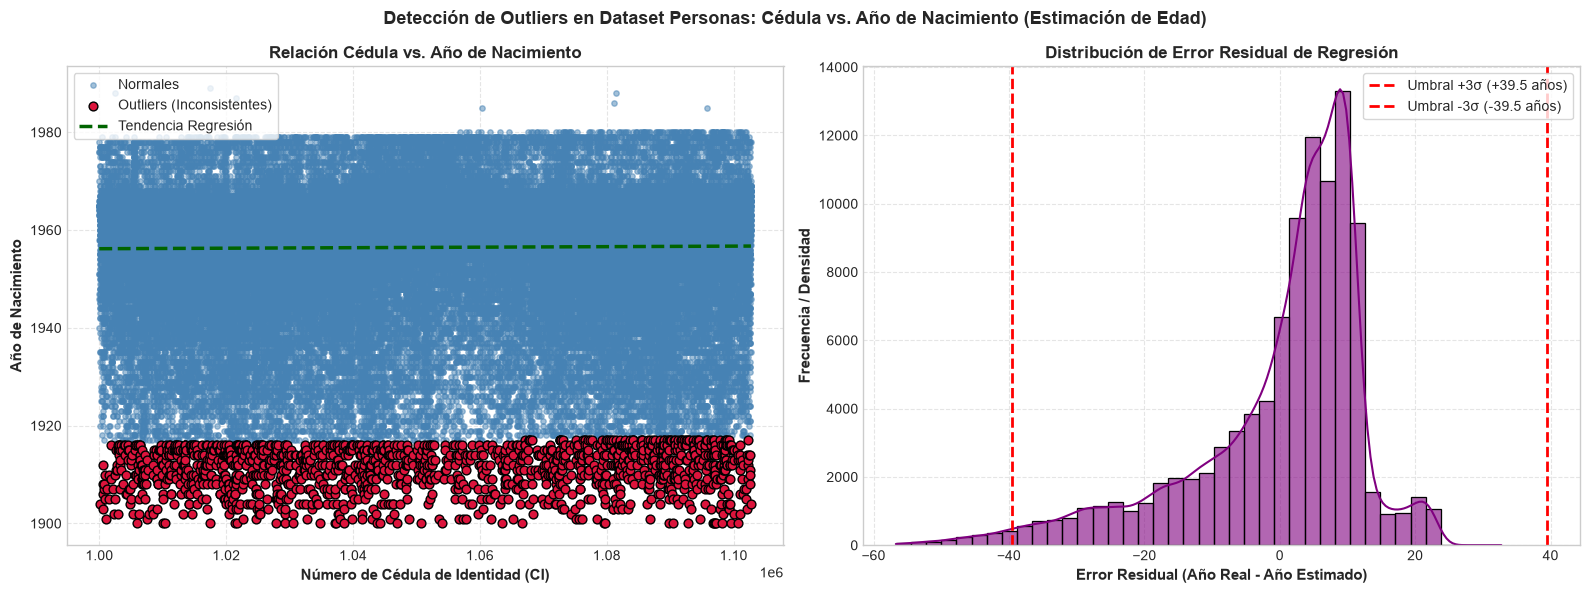

In [85]:
def plot_cedula_age_outlier_dashboard(df: pd.DataFrame, slope: float, intercept: float, std_res: float):
    """Grafica el diagrama de dispersión Cédula vs Año Nacimiento y el mapa de residuales."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Detección de Outliers en Dataset Personas: Cédula vs. Año de Nacimiento (Estimación de Edad)', fontsize=13, fontweight='bold')
    
    normals = df[df['outlier_regresion'] == 0]
    outliers = df[df['outlier_regresion'] == 1]
    
    # Panel 1: Scatter plot Cédula vs Año Nacimiento
    ax1.scatter(normals['cedula_num'], normals['anio_nacimiento'], c='steelblue', s=15, alpha=0.5, label='Normales')
    ax1.scatter(outliers['cedula_num'], outliers['anio_nacimiento'], c='crimson', s=40, edgecolors='black', label='Outliers (Inconsistentes)')
    
    x_vals = np.linspace(df['cedula_num'].min(), df['cedula_num'].max(), 100)
    y_vals = slope * x_vals + intercept
    ax1.plot(x_vals, y_vals, color='darkgreen', linewidth=2.5, linestyle='--', label='Tendencia Regresión')
    
    ax1.set_xlabel('Número de Cédula de Identidad (CI)', fontweight='bold')
    ax1.set_ylabel('Año de Nacimiento', fontweight='bold')
    ax1.set_title('Relación Cédula vs. Año de Nacimiento', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Panel 2: Distribución de Residuales y Umbrales 3-Sigma
    sns.histplot(df['residual'], kde=True, ax=ax2, color='purple', bins=40, alpha=0.6)
    ax2.axvline(x=3*std_res, color='red', linestyle='--', linewidth=2, label=f'Umbral +3σ (+{3*std_res:.1f} años)')
    ax2.axvline(x=-3*std_res, color='red', linestyle='--', linewidth=2, label=f'Umbral -3σ (-{3*std_res:.1f} años)')
    ax2.set_xlabel('Error Residual (Año Real - Año Estimado)', fontweight='bold')
    ax2.set_ylabel('Frecuencia / Densidad', fontweight='bold')
    ax2.set_title('Distribución de Error Residual de Regresión', fontweight='bold')
    ax2.legend(loc='upper right', frameon=True)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_cedula_age_outlier_dashboard(df_personas_analyzed, reg_slope, reg_intercept, res_std)

In [86]:
def load_real_image_dataset_with_ground_truth(n_samples: int = 120) -> tuple:
    """Carga imágenes reales de rostros (Olivetti Faces) e inyecta anomalías etiquetadas."""
    dataset = fetch_olivetti_faces(shuffle=True, random_state=42)
    raw_faces = (dataset.images[:n_samples] * 255).astype(np.uint8)
    
    images = []
    labels_gt = [] # 0: Normal, 1: Outlier
    status_list = []
    
    for i in range(len(raw_faces)):
        img = raw_faces[i].copy()
        h, w = img.shape
        is_outlier = 0
        status = "Normal (Rostro Real)"
        
        if i in [10, 25, 50, 75, 95]:
            is_outlier = 1
            if i == 10:
                img = np.random.randint(0, 5, (h, w), dtype=np.uint8)
                status = "Outlier (Subexpuesta / Pitch Black)"
            elif i == 25:
                img = np.random.randint(250, 256, (h, w), dtype=np.uint8)
                status = "Outlier (Sobreexpuesta / Saturada)"
            elif i == 50:
                noise = np.random.randint(0, 256, (h, w), dtype=np.uint8)
                mask = np.random.rand(h, w) > 0.5
                img = np.where(mask, img, noise)
                status = "Outlier (Ruido Masivo Estática)"
            elif i in [75, 95]:
                img = 255 - img
                status = "Outlier (Inversión Anómala)"
                
        images.append(img)
        labels_gt.append(is_outlier)
        status_list.append(status)
        
    return images, np.array(labels_gt), status_list

imgs_all, y_gt_all, status_all = load_real_image_dataset_with_ground_truth(120)
print(f"Dataset de Imágenes Reales Cargado: {len(imgs_all)} imágenes total ({y_gt_all.sum()} outliers etiquetados).")

Dataset de Imágenes Reales Cargado: 120 imágenes total (5 outliers etiquetados).


## 6. Reducción de Dimensionalidad con PCA y Reconstrucción Intuitiva

### Formulaciones Matemáticas Desglosadas de PCA / Eigenfaces:

1. **Matriz de Covarianza ($\Sigma$)**:
   $$\Sigma = \frac{1}{N-1} X^T X$$
   - *Donde*:
     - $\Sigma \in \mathbb{R}^{D \times D}$: Matriz de covarianza de dimensión $4096 \times 4096$.
     - $X \in \mathbb{R}^{N \times D}$: Matriz de datos de entrenamiento centrada (de dimensión $N=92$ muestras normales $\times D=4096$ píxeles).
     - $N$: Número de imágenes normales en entrenamiento.
     - $D$: Número de características de píxel ($D = 64 \times 64 = 4096$).

2. **Ecuación de Autovalores y Autovectores (Eigenfaces)**:
   $$\Sigma v_k = \lambda_k v_k$$
   - *Donde*:
     - $v_k \in \mathbb{R}^D$: $k$-ésimo autovector ortogonal de dimensión $4096$ (vector autorrostro / *Eigenface*).
     - $\lambda_k$: Autovalor asociado a $v_k$, equivalente a la magnitud de la varianza explicada por la $k$-ésima componente principal.

3. **Matriz Base ($V_K$) y Coordenadas Latentes ($Z$)**:
   $$V_K = [v_1, v_2, \dots, v_K]^T \in \mathbb{R}^{K \times D}$$
   $$Z = X_{scaled} V_K^T \in \mathbb{R}^{N \times K}$$
   - *Donde*:
     - $V_K \in \mathbb{R}^{K \times D}$: **Matriz Base de Componentes** ($K=15$ autorrostros $\times D=4096$ píxeles).
     - $Z \in \mathbb{R}^{N \times K}$: Matriz de coordenadas latentes proyectadas de dimensión comprimida $N \times 15$.
     - $K$: Número de componentes principales retenidos ($K=15$).

4. **Reconstrucción de Imagen y Error MSE de Anomalía**:
   $$\hat{X} = Z V_K \in \mathbb{R}^{N \times D}$$
   $$e_i = \frac{1}{D} \|x_{scaled, i} - \hat{x}_i\|_2^2 = \frac{1}{D} \sum_{j=1}^D (x_{scaled, i, j} - \hat{x}_{i, j})^2$$
   - *Donde*:
     - $\hat{X} \in \mathbb{R}^{N \times D}$: Matriz de imágenes reconstruidas a partir de la matriz base.
     - $e_i$: Error Cuadrático Medio (MSE) de reconstrucción para la imagen $i$.
     - $x_{scaled, i, j}$: Intensidad estandarizada de la imagen $i$ en el píxel $j$.
     - $\hat{x}_{i, j}$: Intensidad reconstruida por PCA para la imagen $i$ en el píxel $j$.

5. **Métricas de Verificación Cuantitativa**:
   $$Precision = \frac{TP}{TP + FP}, \quad Recall = \frac{TP}{TP + FN}, \quad F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$
   - *Donde*:
     - $TP$ (*True Positives*): Outliers reales identificados correctamente como anomalía.
     - $FP$ (*False Positives*): Imágenes normales clasificadas erróneamente como outliers.
     - $FN$ (*False Negatives*): Outliers reales no detectados por el modelo.
     - $TN$ (*True Negatives*): Imágenes normales clasificadas correctamente como normales.

In [89]:
# Partición de imágenes en Train (80%) y Validation/Test (20%)
X_img_all = np.array([img.flatten() for img in imgs_all])

X_img_tr, X_img_te, y_gt_tr, y_gt_te, idx_tr, idx_te = train_test_split(
    X_img_all, y_gt_all, range(len(imgs_all)), test_size=0.20, random_state=42, stratify=y_gt_all
)

print(f"Rostros en Entrenamiento (Train): {len(X_img_tr)} imágenes ({y_gt_tr.sum()} outliers etiquetados)")
print(f"Rostros en Validación (Test):   {len(X_img_te)} imágenes ({y_gt_te.sum()} outliers etiquetados)")

Rostros en Entrenamiento (Train): 96 imágenes (4 outliers etiquetados)
Rostros en Validación (Test):   24 imágenes (1 outliers etiquetados)


 ESTRUCTURA MATRICIAL DE PCA (DATOS DE ENTRENAMIENTO)
Matriz de Entrenamiento Original (X_train):  92 rostros x 4096 píxeles (D=4096)
Matriz Base de Componentes (V_K):            15 autorrostros (K=15) x 4096 píxeles (D=4096)
Matriz de Coordenadas Latentes (Z_train):    92 rostros x 15 dimensiones comprimidas (K=15)
Umbral MSE Derivado en Entrenamiento:        0.3716


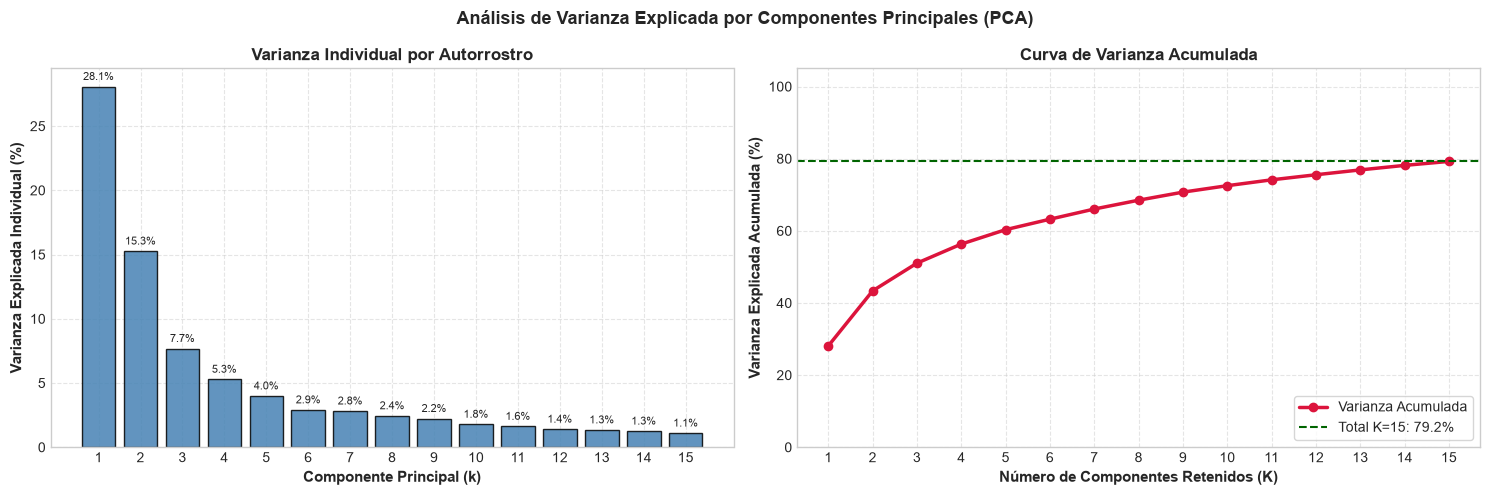

In [90]:
def fit_pca_image_outlier_detector(X_train: np.ndarray, y_train_gt: np.ndarray, n_components: int = 15) -> tuple:
    """Entrena StandardScaler y PCA utilizando preferentemente muestras normales de Train."""
    X_train_normal = X_train[y_train_gt == 0]
    
    scaler = StandardScaler()
    X_tr_scaled_normal = scaler.fit_transform(X_train_normal)
    
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_tr_scaled_normal)
    
    X_tr_scaled_all = scaler.transform(X_train)
    X_tr_rec = pca.inverse_transform(pca.transform(X_tr_scaled_all))
    mse_tr = np.mean(np.square(X_tr_scaled_all - X_tr_rec), axis=1)
    
    threshold = np.mean(mse_tr[y_train_gt == 0]) + 2.5 * np.std(mse_tr[y_train_gt == 0])
    return scaler, pca, threshold

scaler_pca, pca_model, pca_threshold = fit_pca_image_outlier_detector(X_img_tr, y_gt_tr, n_components=15)

# Estructura Matricial de PCA
X_tr_norm = X_img_tr[y_gt_tr == 0]
Z_tr_norm = pca_model.transform(scaler_pca.transform(X_tr_norm))
V_K = pca_model.components_

print("="*65)
print(" ESTRUCTURA MATRICIAL DE PCA (DATOS DE ENTRENAMIENTO)")
print("="*65)
print(f"Matriz de Entrenamiento Original (X_train):  {X_tr_norm.shape[0]} rostros x {X_tr_norm.shape[1]} píxeles (D=4096)")
print(f"Matriz Base de Componentes (V_K):            {V_K.shape[0]} autorrostros (K=15) x {V_K.shape[1]} píxeles (D=4096)")
print(f"Matriz de Coordenadas Latentes (Z_train):    {Z_tr_norm.shape[0]} rostros x {Z_tr_norm.shape[1]} dimensiones comprimidas (K=15)")
print(f"Umbral MSE Derivado en Entrenamiento:        {pca_threshold:.4f}")
print("="*65)

# Gráfico de Varianza Explicada
var_exp = pca_model.explained_variance_ratio_ * 100
var_cum = np.cumsum(var_exp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Análisis de Varianza Explicada por Componentes Principales (PCA)', fontsize=13, fontweight='bold')

bars = ax1.bar(range(1, len(var_exp) + 1), var_exp, color='steelblue', edgecolor='black', alpha=0.85)
ax1.set_xlabel('Componente Principal (k)', fontweight='bold')
ax1.set_ylabel('Varianza Explicada Individual (%)', fontweight='bold')
ax1.set_title('Varianza Individual por Autorrostro', fontweight='bold')
ax1.set_xticks(range(1, len(var_exp) + 1))
ax1.grid(True, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8, rotation=0)

ax2.plot(range(1, len(var_cum) + 1), var_cum, marker='o', color='crimson', linewidth=2.5, markersize=6, label='Varianza Acumulada')
ax2.axhline(y=var_cum[-1], color='darkgreen', linestyle='--', linewidth=1.5, label=f'Total K=15: {var_cum[-1]:.1f}%')
ax2.set_xlabel('Número de Componentes Retenidos (K)', fontweight='bold')
ax2.set_ylabel('Varianza Explicada Acumulada (%)', fontweight='bold')
ax2.set_title('Curva de Varianza Acumulada', fontweight='bold')
ax2.set_xticks(range(1, len(var_cum) + 1))
ax2.set_ylim([0, 105])
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

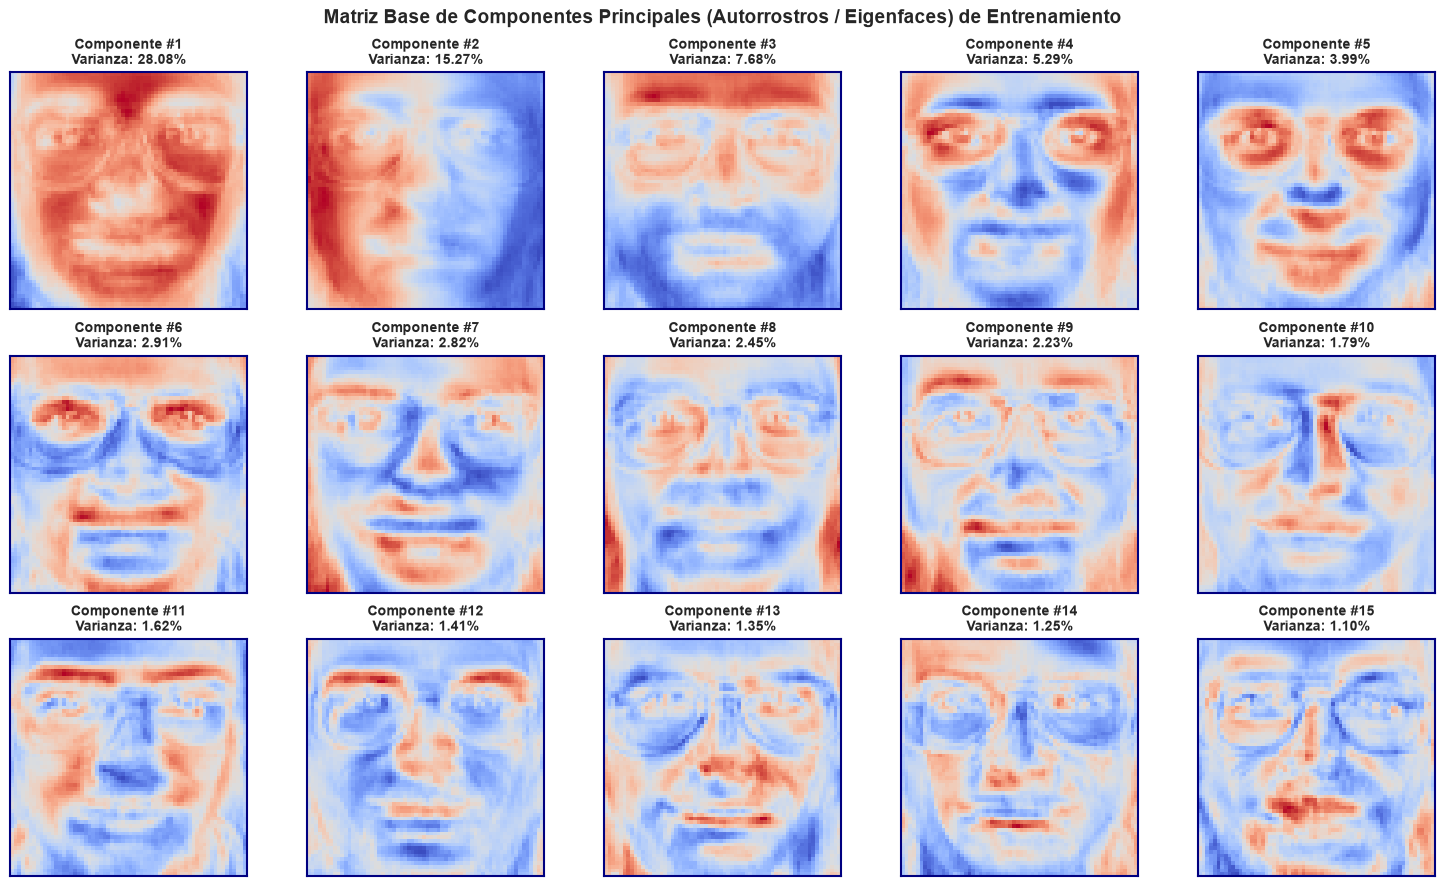

In [91]:
def plot_pca_base_matrix_eigenfaces(pca: PCA, image_shape: tuple = (64, 64), n_components_to_show: int = 15):
    """Visualiza la matriz base V_K formada por los autorrostros (Eigenfaces) entrenados."""
    components = pca.components_[:n_components_to_show]
    var_ratios = pca.explained_variance_ratio_[:n_components_to_show] * 100
    
    n_rows = 3
    n_cols = 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
    fig.suptitle('Matriz Base de Componentes Principales (Autorrostros / Eigenfaces) de Entrenamiento', fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        if i < len(components):
            eigenface = components[i].reshape(image_shape)
            im = ax.imshow(eigenface, cmap='coolwarm')
            ax.set_title(f'Componente #{i+1}\nVarianza: {var_ratios[i]:.2f}%', fontsize=10, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor('navy')
                spine.set_linewidth(1.5)
        else:
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

plot_pca_base_matrix_eigenfaces(pca_model, image_shape=(64, 64), n_components_to_show=15)

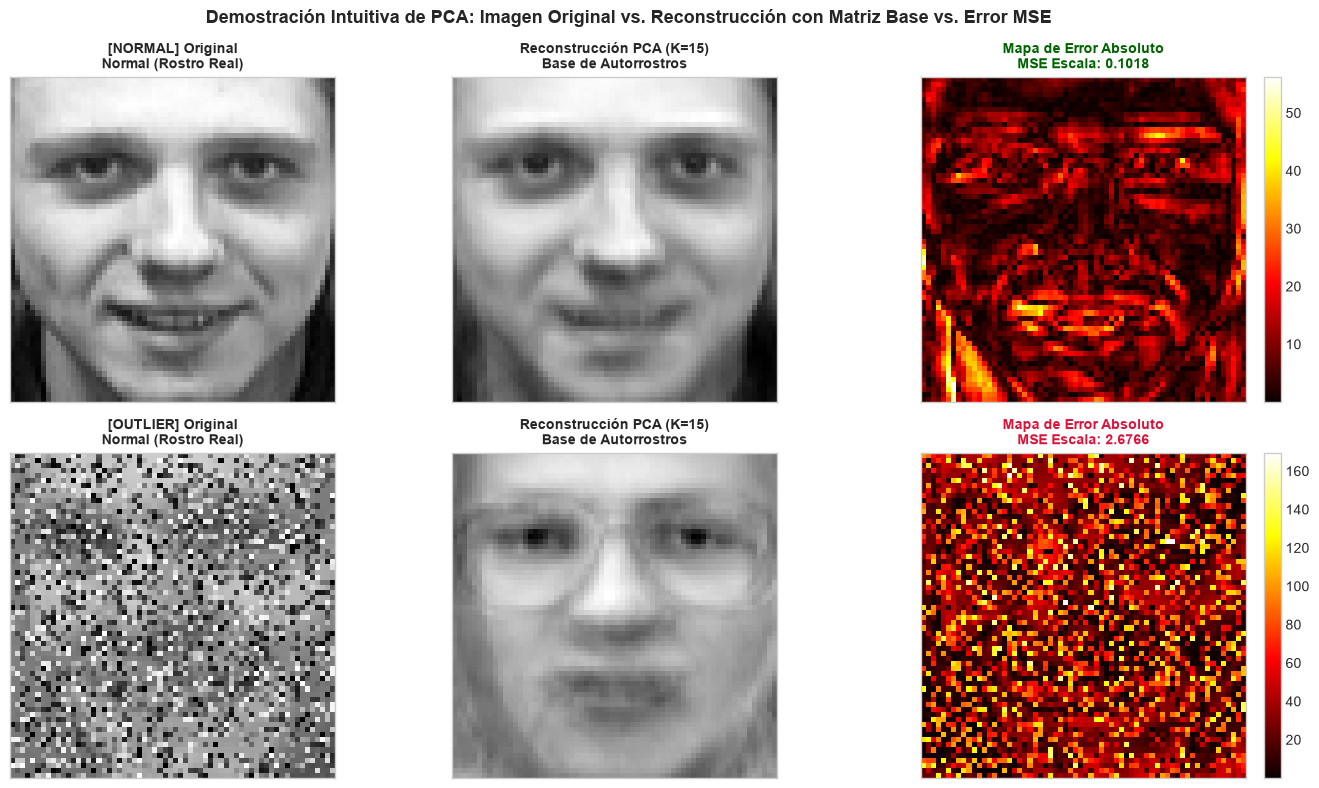

In [92]:
def plot_pca_reconstruction_intuition(scaler: StandardScaler, pca: PCA, X_img_data: np.ndarray, y_gt_data: np.ndarray, status_list: list, idx_sample_normal: int = 0, idx_sample_outlier: int = 0):
    """Muestra la reconstrucción intuitiva: Imagen Original vs Reconstrucción PCA vs Mapa de Error absoluto."""
    normal_indices = np.where(y_gt_data == 0)[0]
    outlier_indices = np.where(y_gt_data == 1)[0]
    
    idx_norm = normal_indices[idx_sample_normal]
    idx_out = outlier_indices[idx_sample_outlier]
    
    selected_indices = [idx_norm, idx_out]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle('Demostración Intuitiva de PCA: Imagen Original vs. Reconstrucción con Matriz Base vs. Error MSE', fontsize=13, fontweight='bold')
    
    for row, idx in enumerate(selected_indices):
        img_raw = X_img_data[idx]
        img_scaled = scaler.transform([img_raw])
        img_rec_scaled = pca.inverse_transform(pca.transform(img_scaled))
        
        img_orig_2d = img_raw.reshape(64, 64)
        img_rec_2d = scaler.inverse_transform(img_rec_scaled).reshape(64, 64)
        diff_2d = np.abs(img_orig_2d - img_rec_2d)
        
        mse_val = np.mean(np.square(img_scaled - img_rec_scaled))
        gt_label = "NORMAL" if y_gt_data[idx] == 0 else "OUTLIER"
        status_txt = status_list[idx] if idx < len(status_list) else gt_label
        
        axes[row, 0].imshow(img_orig_2d, cmap='gray')
        axes[row, 0].set_title(f'[{gt_label}] Original\n{status_txt}', fontsize=10, fontweight='bold')
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        
        axes[row, 1].imshow(img_rec_2d, cmap='gray')
        axes[row, 1].set_title(f'Reconstrucción PCA (K=15)\nBase de Autorrostros', fontsize=10, fontweight='bold')
        axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])
        
        im_err = axes[row, 2].imshow(diff_2d, cmap='hot')
        color_err = 'darkgreen' if y_gt_data[idx] == 0 else 'crimson'
        axes[row, 2].set_title(f'Mapa de Error Absoluto\nMSE Escala: {mse_val:.4f}', fontsize=10, fontweight='bold', color=color_err)
        axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])
        fig.colorbar(im_err, ax=axes[row, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

plot_pca_reconstruction_intuition(scaler_pca, pca_model, X_img_tr, y_gt_tr, status_all, idx_sample_normal=0, idx_sample_outlier=0)

In [93]:
def evaluate_pca_outlier_predictions(scaler, pca, threshold, X_data, y_true_gt, set_name="Validation/Test") -> tuple:
    """Aplica el modelo PCA ajustado y verifica cuantitativamente el desempeño en Test."""
    X_scaled = scaler.transform(X_data)
    X_rec = pca.inverse_transform(pca.transform(X_scaled))
    mse_errors = np.mean(np.square(X_scaled - X_rec), axis=1)
    
    y_pred_outliers = (mse_errors > threshold).astype(int)
    
    prec, rec, f1, _ = precision_recall_fscore_support(y_true_gt, y_pred_outliers, average='binary', zero_division=0)
    cm = confusion_matrix(y_true_gt, y_pred_outliers)
    
    print(f"\n================ VERIFICACIÓN CUANTITATIVA EN {set_name.upper()} ================")
    print(f"Matriz de Confusión:\n{cm}")
    print(f"Precisión (Precision):  {prec:.4f}")
    print(f"Exhaustividad (Recall): {rec:.4f}")
    print(f"Puntaje F1 (F1-Score):   {f1:.4f}")
    
    return y_pred_outliers, mse_errors

y_pred_te, mse_test = evaluate_pca_outlier_predictions(scaler_pca, pca_model, pca_threshold, X_img_te, y_gt_te, "Validation/Test")


================ VERIFICACIÓN CUANTITATIVA EN VALIDATION/TEST ================
Matriz de Confusión:
[[18  5]
 [ 0  1]]
Precisión (Precision):  0.1667
Exhaustividad (Recall): 1.0000
Puntaje F1 (F1-Score):   0.2857


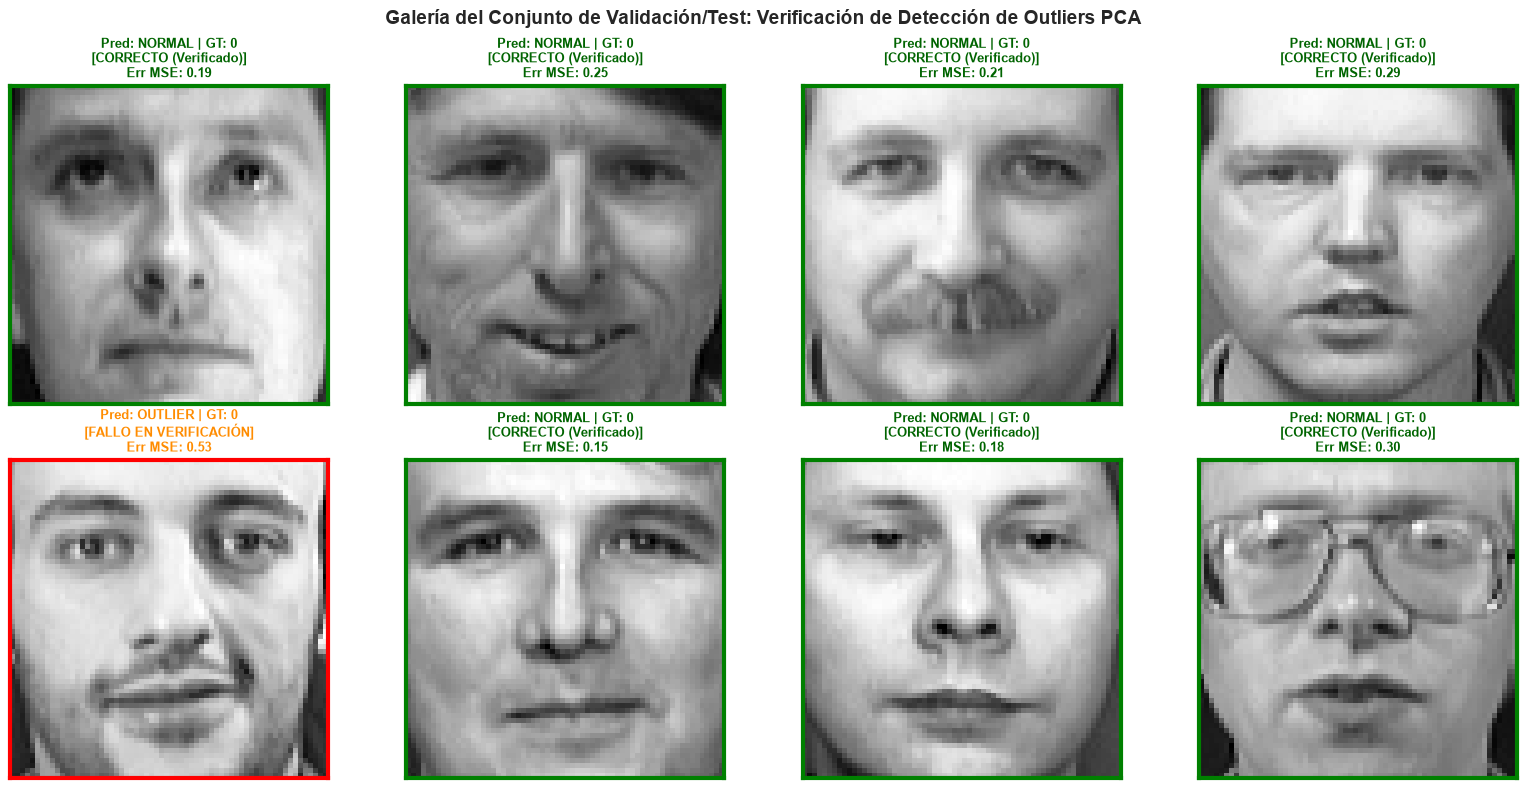

In [94]:
def plot_verified_image_outlier_gallery(imgs_all: list, idx_test: list, y_gt_te: np.ndarray, y_pred_te: np.ndarray, mse_test: np.ndarray):
    """Muestra la galería de imágenes del conjunto de validación indicando la verificación real."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Galería del Conjunto de Validación/Test: Verificación de Detección de Outliers PCA', fontsize=14, fontweight='bold')
    
    for i in range(min(8, len(idx_test))):
        row = i // 4
        col = i % 4
        orig_idx = idx_test[i]
        img = imgs_all[orig_idx]
        
        gt = y_gt_te[i]
        pred = y_pred_te[i]
        err = mse_test[i]
        
        ax = axes[row, col]
        ax.imshow(img, cmap='gray')
        
        if gt == pred:
            match_status = "CORRECTO (Verificado)"
            color = 'darkgreen' if gt == 0 else 'crimson'
        else:
            match_status = "FALLO EN VERIFICACIÓN"
            color = 'darkorange'
            
        label_text = "OUTLIER" if pred == 1 else "NORMAL"
        ax.set_title(f"Pred: {label_text} | GT: {gt}\n[{match_status}]\nErr MSE: {err:.2f}", color=color, fontweight='bold', fontsize=9)
        
        border_color = 'red' if pred == 1 else 'green'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            
        ax.set_xticks([]); ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

plot_verified_image_outlier_gallery(imgs_all, idx_te, y_gt_te, y_pred_te, mse_test)

## 7. Encapsulamiento en Pipeline de Producción y Resumen Pedagógico

En producción, la imputación, la normalización estandarizada (`StandardScaler`) y la codificación categórica (`OneHotEncoder`) se integran mediante `ColumnTransformer` para garantizar reproducibilidad y prevenir la fuga de información.

In [95]:
def build_production_pipeline(num_features: list, cat_features: list) -> ColumnTransformer:
    """Crea un ColumnTransformer modular de Scikit-Learn."""
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ])

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols = ['Sex', 'Pclass', 'Embarked']

pipeline = build_production_pipeline(num_cols, cat_cols)
X_tr_proc = pipeline.fit_transform(df_train)
X_te_proc = pipeline.transform(df_test)

print(f"Matriz de entrenamiento procesada en Pipeline: {X_tr_proc.shape}")
print(f"Matriz de validación procesada en Pipeline:    {X_te_proc.shape}")

Matriz de entrenamiento procesada en Pipeline: (712, 9)
Matriz de validación procesada en Pipeline:    (179, 9)


## Resumen

1. **Granularidad y Modularidad**: Dividir el código en funciones independientes con tipado explícito y celdas enfocadas.
2. **Mecanismos de Ausencia de Datos**: Comprender la diferencia entre MCAR, MAR y MNAR para elegir entre eliminación directa (`dropna`) e imputación multivariada (`KNNImputer`).
3. **Normalización de Datos**: Comparar empíricamente `StandardScaler` (Z-Score), `MinMaxScaler` y `RobustScaler` evaluando métricas y distribuciones cuantitativas.
4. **Partición sin Data Leakage**: Entrenar transformadores, modelos de regresión, estimadores de outliers e imputadores únicamente en el conjunto de **Train**.
5. **Outliers e Inconsistencias de Dominio**: Aplicar IQR, Isolation Forest y análisis de residuales $Z > 3\sigma$ en relaciones reales (Cédula vs. Año de Nacimiento).
6. **PCA y Representación por Matriz Base**: Proyectar datos a autorrostros ($V_K$), graficar la varianza explicada y utilizar el error MSE de reconstrucción para la detección de anomalías.